# Density Estimation Full Flow
End-to-end notebook for ShanghaiTech crowd density using GT head points, optional YOLO, zone assignment, heatmap, and batch processing.

In [ ]:
# Optional install (run once per environment)
# %pip install numpy opencv-python matplotlib scipy
# %pip install ultralytics  # optional for YOLO section

## 1) Imports and Setup

In [4]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, "../")

from src.density_estimation import (
    DEFAULT_SHANGHAITECH_ROOT,
    draw_density_debug,
    get_head_points,
    get_shanghaitech_split_paths,
    process_frame_density,
    process_image_directory,
)

print("Density estimation imports successful")

ImportError: cannot import name 'YoloDetector' from 'src.density_estimation.yolo_detector' (c:\Users\Lokesh Kumar\OneDrive\Desktop\HS202_G18\notebooks\..\src\density_estimation\yolo_detector.py)

## 2) Configure Dataset Path and Grid

In [ ]:
# Select ShanghaiTech split
part = "A"      # "A" or "B"
split = "test"  # "train" or "test"

shanghaitech_root = Path("../Shanghai Tech").expanduser()
if not shanghaitech_root.exists():
    shanghaitech_root = Path("../ShanghaiTech").expanduser()
if not shanghaitech_root.exists():
    shanghaitech_root = Path(DEFAULT_SHANGHAITECH_ROOT)

print(f"Using ShanghaiTech dataset root: {shanghaitech_root}")

images_dir, gt_dir = get_shanghaitech_split_paths(
    dataset_root=shanghaitech_root,
    part=part,
    split=split,
)

# Replace with Team 1 grid if available
grid = {
    "z0": (0, 0, 512, 384),
    "z1": (512, 0, 1024, 384),
    "z2": (0, 384, 512, 768),
    "z3": (512, 384, 1024, 768),
}


Images directory: C:\Users\pingm\Personal Folder\Development\College Projects\Datasets for HS202\Shanghai Tech\part_A_final\test_data\images
GT directory: C:\Users\pingm\Personal Folder\Development\College Projects\Datasets for HS202\Shanghai Tech\part_A_final\test_data\ground_truth
Grid zones: ['z0', 'z1', 'z2', 'z3']


## 3) Single-Frame Ground Truth Density Test

In [3]:
image_paths = sorted(
    [p for p in Path(images_dir).iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
)
assert image_paths, "No images found in selected images directory"

image_path = image_paths[0]
frame_id = image_path.stem
annotation_path = Path(gt_dir) / f"GT_{frame_id}.mat"
assert annotation_path.exists(), f"Missing annotation file: {annotation_path}"

single_result = process_frame_density(
    image_path=image_path,
    annotation_path=annotation_path,
    grid=grid,
    use_yolo=False,
    normalize=False,
)

print("Frame:", single_result["frame_id"])
print("Zone density:", single_result["zone_density"])

Frame: IMG_1
Zone density: {'z0': 87, 'z1': 82, 'z2': 2, 'z3': 1}


## 4) Debug Visualization (Grid + Points + Zone Counts)

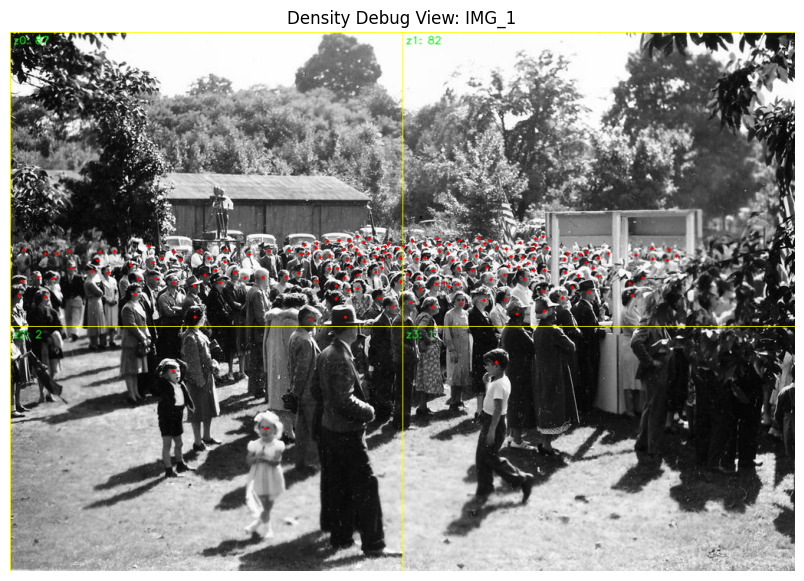

In [4]:
img_bgr = cv2.imread(str(image_path))
head_points = get_head_points(annotation_path)

debug_bgr = draw_density_debug(
    image=img_bgr,
    grid=grid,
    points=head_points,
    zone_density=single_result["zone_density"],
    show_zone_counts=True,
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(debug_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Density Debug View: {frame_id}")
plt.axis("off")
plt.show()

## 5) Heatmap Visualization (Single Frame)

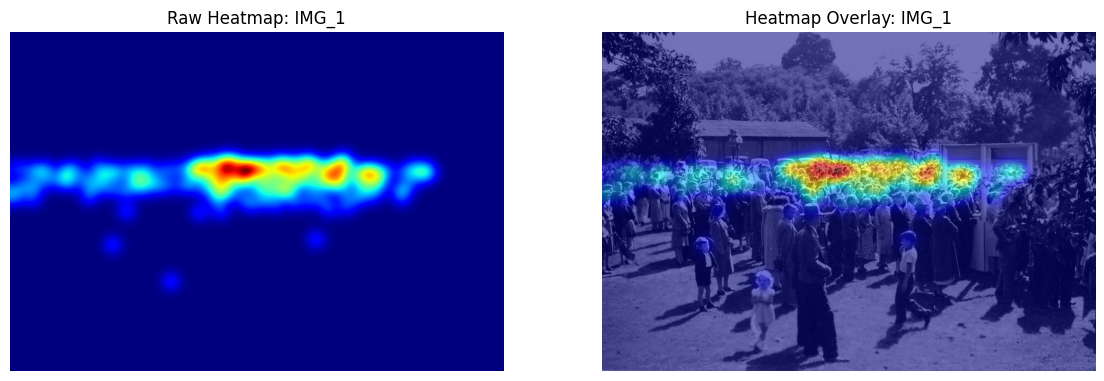

In [5]:
h, w = img_bgr.shape[:2]
density = np.zeros((h, w), dtype=np.float32)

for x, y in head_points:
    xi = int(round(x))
    yi = int(round(y))
    if 0 <= xi < w and 0 <= yi < h:
        density[yi, xi] += 1.0

heat = cv2.GaussianBlur(density, (0, 0), sigmaX=15, sigmaY=15)
heat_norm = cv2.normalize(heat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
heat_color = cv2.applyColorMap(heat_norm, cv2.COLORMAP_JET)

alpha = 0.55
overlay_bgr = cv2.addWeighted(img_bgr, 1 - alpha, heat_color, alpha, 0)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(heat_norm, cmap="jet")
plt.title(f"Raw Heatmap: {frame_id}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Heatmap Overlay: {frame_id}")
plt.axis("off")
plt.show()

## 6) Batch Density Processing

In [6]:
density_map = process_image_directory(
    images_dir=images_dir,
    annotations_dir=gt_dir,
    grid=grid,
    use_yolo=False,
    normalize=False,
)

print("Total frames processed:", len(density_map))
sample_frame = next(iter(density_map))
print("Sample output:", sample_frame, density_map[sample_frame])

Total frames processed: 182
Sample output: IMG_1 {'z0': 87, 'z1': 82, 'z2': 2, 'z3': 1}


## 7) Quality Checks

In [7]:
assert len(density_map) > 0, "Batch density map is empty"
all_zones = set(grid.keys())
first_key = next(iter(density_map))
assert set(density_map[first_key].keys()) == all_zones, "Zone keys mismatch"

total_people_first = sum(density_map[first_key].values())
print("First frame:", first_key)
print("Total counted points in first frame:", total_people_first)

totals = [sum(z.values()) for z in density_map.values()]
print("Min points/frame:", int(np.min(totals)))
print("Max points/frame:", int(np.max(totals)))
print("Mean points/frame:", float(np.mean(totals)))

First frame: IMG_1
Total counted points in first frame: 172
Min points/frame: 66
Max points/frame: 2256
Mean points/frame: 432.63186813186815


## 8) Optional YOLO Mode

In [8]:
try:
    yolo_result = process_frame_density(
        image_path=image_path,
        grid=grid,
        use_yolo=True,
        yolo_kwargs={"model_path": "yolov8n.pt", "conf": 0.25},
    )
    print("YOLO zone density:", yolo_result["zone_density"])
except Exception as exc:
    print("YOLO test skipped or failed:", exc)

YOLO zone density: {'z0': 2, 'z1': 0, 'z2': 8, 'z3': 7}
